# SOH Forecast Model Runner

This notebook runs the reusable forecast model files on one shared chronological split for observed SOH targets. It keeps feature engineering, benchmarking, and cycle-based graphing aligned across flight-count horizons so the comparison is fair.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def bootstrap_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "ml_workspace").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate repo root")


REPO_ROOT = bootstrap_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml_workspace.soh_forecast.benchmarking import (
    build_full_and_common_metrics,
    build_truth_frame,
    combine_prediction_tables,
    gbdt_importance_frame,
    get_metric,
    ridge_coefficient_frame,
    summarize_feature_correlation,
)
from ml_workspace.soh_forecast.common import TargetSpec, set_seed
from ml_workspace.soh_forecast.feature_pipeline import (
    add_forecast_features,
    assign_shared_splits,
    available_feature_sets,
    load_latent_dataset,
    make_multi_horizon_target_specs,
    split_frames_from_assigned,
)
from ml_workspace.soh_forecast.models.elastic_net_delta import train_elastic_net_delta
from ml_workspace.soh_forecast.models.gam_spline_delta import train_gam_spline_delta
from ml_workspace.soh_forecast.models.gru_sequence import train_gru_sequence
from ml_workspace.soh_forecast.models.hist_gbdt_delta import train_hist_gbdt_delta
from ml_workspace.soh_forecast.models.lstm_sequence import train_lstm_sequence
from ml_workspace.soh_forecast.models.naive_zero_delta import train_naive_zero_delta
from ml_workspace.soh_forecast.models.physics_hybrid_nn import PhysicsHybridConfig, train_physics_hybrid_nn
from ml_workspace.soh_forecast.models.physics_informed_nn import PhysicsInformedConfig, train_physics_informed_nn
from ml_workspace.soh_forecast.models.random_forest_delta import train_random_forest_delta
from ml_workspace.soh_forecast.models.ridge_delta import train_ridge_delta
from ml_workspace.soh_forecast.models.lstm_sequence import LSTMConfig

set_seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 240)

PRIMARY_PLANE = "166"
HOLDOUT_PLANE = "192"
RUN_LATENT_PIPELINE = False
RT_PROFILE = "balanced"
Q_DAY_SIGMA_PCT = 0.05
COMPARE_BACKEND = True
TRAIN_FRAC = 0.70
VALID_FRAC = 0.15
LOOKBACK = 12

# Keeping the default comparison set modest prevents the notebook runtime from exploding.
HORIZON_CONFIGS = (
    {"kind": "flight", "value": 1, "label": "flight_1", "title": "Next flight"},
    {"kind": "flight", "value": 5, "label": "flight_5", "title": "Next 5 flights"},
    {"kind": "flight", "value": 10, "label": "flight_10", "title": "Next 10 flights"},
)
TARGET_SPECS = make_multi_horizon_target_specs(horizon_configs=HORIZON_CONFIGS, include_observed=True, include_latent=False)

OUTPUT_DIR = REPO_ROOT / "ml_workspace" / "soh_forecast" / "output" / f"observed_target_runner_plane_{PRIMARY_PLANE}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", REPO_ROOT)
print("Output dir:", OUTPUT_DIR)
print("Targets:", list(TARGET_SPECS))




Repo root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane
Output dir: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/output/observed_target_runner_plane_166
Targets: ['observed_flight_1', 'observed_flight_5', 'observed_flight_10']


## Load event table and build one shared split

The split assignment is created once on the primary plane chronology and then reused across the observed SOH horizons. The optional holdout plane stays completely outside train, validation, and test.

In [2]:
latent_df, summaries = load_latent_dataset(
    repo_root=REPO_ROOT,
    primary_plane=PRIMARY_PLANE,
    holdout_plane=HOLDOUT_PLANE,
    run_latent_pipeline=RUN_LATENT_PIPELINE,
    rt_profile=RT_PROFILE,
    q_day_sigma_pct=Q_DAY_SIGMA_PCT,
    compare_backend=COMPARE_BACKEND,
)
forecast_df = add_forecast_features(latent_df)
feature_sets = available_feature_sets(forecast_df)

shared_df = assign_shared_splits(
    forecast_df,
    primary_plane=PRIMARY_PLANE,
    holdout_plane=HOLDOUT_PLANE,
    train_frac=TRAIN_FRAC,
    valid_frac=VALID_FRAC,
)
shared_splits = split_frames_from_assigned(shared_df)

target_coverage_rows = []
for target_name, target_spec in TARGET_SPECS.items():
    usable = shared_df.loc[shared_df[target_spec.next_col].notna()].copy()
    if usable.empty:
        continue
    for split_name, frame in [("train", usable.loc[usable['split'].eq('train')]), ("valid", usable.loc[usable['split'].eq('valid')]), ("test", usable.loc[usable['split'].eq('test')]), ("holdout", usable.loc[usable['split'].eq('holdout')])]:
        if frame.empty:
            continue
        target_coverage_rows.append({
            "target_name": target_name,
            "title": target_spec.title_label,
            "split": split_name,
            "rows": int(len(frame)),
        })

display(pd.DataFrame(list(summaries.values())))
display(shared_df.groupby(["split", "plane_id", "battery_id"], as_index=False).size().rename(columns={"size": "rows"}))
display(pd.DataFrame([{"feature_group": key, "n_features": len(value)} for key, value in feature_sets.items()]))
display(pd.DataFrame(target_coverage_rows))
print("Shared rows:", len(shared_df))
print("train / valid / test / holdout:", len(shared_splits.train), len(shared_splits.valid), len(shared_splits.test), len(shared_splits.holdout))



/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/feature_pipeline.py:443: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g["soc_edge_stress_proxy"] = np.minimum(g["soc_mean_pct"], 100.0 - g["soc_mean_pct"]).rsub(50.0).clip(lower=0.0) * (g["soc_span_pct"].clip(lower=0.0) / 100.0)
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/feature_pipeline.py:444: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  g["storage_stress_proxy"] = g["delta_days"].clip(lower=0.0) * (g["soc

,plane_id,rt_profile,battery_ids_processed,n_events_total,n_events_per_battery,n_events_dropped_missing_observed_soh,sigma_base_pct_per_battery,q_day_sigma_pct,raw_total_variation_per_battery,smoothed_total_variation_per_battery,raw_max_upward_jump_pct_per_battery,smoothed_max_upward_jump_pct_per_battery,fraction_events_with_condition_multiplier_gt_3,notes
0,166,balanced,"[1, 2]",1106,"{'1': 553, '2': 553}",0,"{'1': 0.55, '2': 0.55}",0.05,"{'1': 484.0, '2': 469.0}","{'1': 51.14722851352783, '2': 49.6942665930803}","{'1': 29.0, '2': 25.0}","{'1': 1.0244025838651254, '2': 1.0229620160775...","{'1': 0.2766726943942134, '2': 0.2567811934900...",FilterPy latent SOH is the canonical output. P...
1,192,balanced,"[1, 2]",98,"{'1': 49, '2': 49}",0,"{'1': 0.55, '2': 0.55}",0.05,"{'1': 5.0, '2': 5.0}","{'1': 0.8559490722647354, '2': 0.7980700292446...","{'1': 0.0, '2': 0.0}","{'1': -1.2547329788503703e-06, '2': -1.1689867...","{'1': 0.10204081632653061, '2': 0.102040816326...",FilterPy latent SOH is the canonical output. P...


,split,plane_id,battery_id,rows
0,holdout,192,1,49
1,holdout,192,2,49
2,test,166,1,83
3,test,166,2,83
4,train,166,1,387
5,train,166,2,387
6,valid,166,1,83
7,valid,166,2,83


,feature_group,n_features
0,raw,21
1,operating,38
2,latent,7
3,physics,16
4,static_numeric,5
5,static_categorical,3
6,history,37


,target_name,title,split,rows
0,observed_flight_1,Observed SOH (Next flight),train,774
1,observed_flight_1,Observed SOH (Next flight),valid,166
2,observed_flight_1,Observed SOH (Next flight),test,160
3,observed_flight_1,Observed SOH (Next flight),holdout,94
4,observed_flight_5,Observed SOH (Next 5 flights),train,774
5,observed_flight_5,Observed SOH (Next 5 flights),valid,166
6,observed_flight_5,Observed SOH (Next 5 flights),test,136
7,observed_flight_5,Observed SOH (Next 5 flights),holdout,70
8,observed_flight_10,Observed SOH (Next 10 flights),train,774
9,observed_flight_10,Observed SOH (Next 10 flights),valid,166


Shared rows: 1204
train / valid / test / holdout: 774 166 166 98


## Benchmark helper

Each target reuses the same model files, feature groups, and split labels. Outputs are saved under one target-specific folder.

In [3]:
def run_target_benchmark(target_spec: TargetSpec) -> dict[str, object]:
    target_df = shared_df.loc[shared_df[target_spec.next_col].notna()].copy()
    split_frames = split_frames_from_assigned(target_df)

    raw_features = feature_sets["raw"]
    operating_features = feature_sets.get("operating", [])
    latent_features = feature_sets["latent"]
    physics_features = feature_sets.get("physics", [])
    static_numeric_features = feature_sets.get("static_numeric", [])
    history_features = feature_sets["history"]
    all_features = list(dict.fromkeys(raw_features + operating_features + latent_features + physics_features + static_numeric_features + history_features))
    corr_df = summarize_feature_correlation(target_df, all_features, target_spec)

    artifacts = [
        train_naive_zero_delta(split_frames, target_spec),
        train_ridge_delta(split_frames, target_spec, raw_features, model_name="ridge_raw_only"),
        train_ridge_delta(split_frames, target_spec, raw_features + latent_features, model_name="ridge_raw_plus_latent"),
        train_elastic_net_delta(split_frames, target_spec, all_features, model_name="elastic_raw_plus_latent_plus_history"),
        train_ridge_delta(split_frames, target_spec, all_features, model_name="ridge_raw_plus_latent_plus_history"),
        train_hist_gbdt_delta(split_frames, target_spec, all_features, model_name="gbdt_raw_plus_latent_plus_history"),
        train_random_forest_delta(split_frames, target_spec, all_features, model_name="random_forest_raw_plus_latent_plus_history"),
        train_gam_spline_delta(split_frames, target_spec, all_features, model_name="gam_spline_raw_plus_latent_plus_history"),
        train_lstm_sequence(
            target_df,
            split_frames,
            target_spec,
            all_features,
            model_name="lstm_sequence",
            config=LSTMConfig(lookback=LOOKBACK, device="cpu"),
        ),
        train_gru_sequence(
            target_df,
            split_frames,
            target_spec,
            all_features,
            model_name="gru_sequence",
            config=LSTMConfig(lookback=LOOKBACK, device="cpu"),
        ),
        train_physics_hybrid_nn(
            split_frames,
            target_spec,
            all_features,
            model_name="physics_hybrid_nn",
            config=PhysicsHybridConfig(device="cpu"),
        ),
        train_physics_informed_nn(
            split_frames,
            target_spec,
            all_features,
            model_name="physics_informed_pinn",
            config=PhysicsInformedConfig(device="cpu"),
        ),
    ]

    artifacts_by_name = {artifact.model_name: artifact for artifact in artifacts}
    model_metrics = pd.concat([artifact.metrics for artifact in artifacts if not artifact.metrics.empty], ignore_index=True)
    all_predictions = combine_prediction_tables(artifacts)
    truth_frame = build_truth_frame(target_df, target_spec)
    benchmark_df = truth_frame.merge(all_predictions, on=["event_id", "split"], how="left")

    comparison_models = [
        "naive_zero_delta",
        "ridge_raw_only",
        "ridge_raw_plus_latent",
        "elastic_raw_plus_latent_plus_history",
        "ridge_raw_plus_latent_plus_history",
        "gbdt_raw_plus_latent_plus_history",
        "random_forest_raw_plus_latent_plus_history",
        "gam_spline_raw_plus_latent_plus_history",
        "lstm_sequence",
        "gru_sequence",
        "physics_hybrid_nn",
        "physics_informed_pinn",
    ]
    full_available_metrics, common_subset_metrics, common_subset = build_full_and_common_metrics(
        benchmark_df,
        target_spec,
        comparison_models,
    )

    ridge_coef_df = ridge_coefficient_frame(artifacts_by_name["ridge_raw_plus_latent_plus_history"])
    gbdt_importance_df = gbdt_importance_frame(artifacts_by_name["gbdt_raw_plus_latent_plus_history"])
    lstm_history_df = artifacts_by_name["lstm_sequence"].diagnostics.get("history", pd.DataFrame())
    gru_history_df = artifacts_by_name["gru_sequence"].diagnostics.get("history", pd.DataFrame())
    hybrid_history_df = artifacts_by_name["physics_hybrid_nn"].diagnostics.get("history", pd.DataFrame())
    pinn_history_df = artifacts_by_name["physics_informed_pinn"].diagnostics.get("history", pd.DataFrame())

    target_output_dir = OUTPUT_DIR / target_spec.name
    target_output_dir.mkdir(parents=True, exist_ok=True)
    benchmark_df.to_csv(target_output_dir / f"{target_spec.name}_predictions.csv", index=False)
    model_metrics.to_csv(target_output_dir / f"{target_spec.name}_metrics_all_rows.csv", index=False)
    full_available_metrics.to_csv(target_output_dir / f"{target_spec.name}_metrics_by_available_predictions.csv", index=False)
    common_subset_metrics.to_csv(target_output_dir / f"{target_spec.name}_metrics_common_subset.csv", index=False)
    corr_df.to_csv(target_output_dir / f"{target_spec.name}_feature_correlations.csv")
    ridge_coef_df.to_csv(target_output_dir / f"{target_spec.name}_ridge_coefficients.csv", index=False)
    gbdt_importance_df.to_csv(target_output_dir / f"{target_spec.name}_gbdt_importance.csv", index=False)
    if not lstm_history_df.empty:
        lstm_history_df.to_csv(target_output_dir / f"{target_spec.name}_lstm_learning_curve.csv", index=False)
    if not gru_history_df.empty:
        gru_history_df.to_csv(target_output_dir / f"{target_spec.name}_gru_learning_curve.csv", index=False)
    if not hybrid_history_df.empty:
        hybrid_history_df.to_csv(target_output_dir / f"{target_spec.name}_physics_hybrid_learning_curve.csv", index=False)
    if not pinn_history_df.empty:
        pinn_history_df.to_csv(target_output_dir / f"{target_spec.name}_physics_informed_pinn_learning_curve.csv", index=False)

    return {
        "target_spec": target_spec,
        "split_frames": split_frames,
        "artifacts": artifacts,
        "artifacts_by_name": artifacts_by_name,
        "corr_df": corr_df,
        "benchmark_df": benchmark_df,
        "model_metrics": model_metrics,
        "full_available_metrics": full_available_metrics,
        "common_subset_metrics": common_subset_metrics,
        "common_subset": common_subset,
        "ridge_coef_df": ridge_coef_df,
        "gbdt_importance_df": gbdt_importance_df,
        "lstm_history_df": lstm_history_df,
        "gru_history_df": gru_history_df,
        "hybrid_history_df": hybrid_history_df,
        "pinn_history_df": pinn_history_df,
        "output_dir": target_output_dir,
    }



In [4]:
results = {}
summary_rows = []
for target_name, target_spec in TARGET_SPECS.items():
    print(f"=== Running {target_name} benchmark ===")
    results[target_name] = run_target_benchmark(target_spec)
    test_metrics = results[target_name]["common_subset_metrics"].loc[
        results[target_name]["common_subset_metrics"]["eval_split"].eq("test")
    ].sort_values("level_mae")
    display(test_metrics[["model", "level_mae", "level_rmse", "level_r2", "delta_r2"]].round(4))
    if not test_metrics.empty:
        best_row = test_metrics.iloc[0]
        summary_rows.append(
            {
                "target_name": target_name,
                "title": target_spec.title_label,
                "best_model": best_row["model"],
                "test_level_mae": float(best_row["level_mae"]),
                "test_level_rmse": float(best_row["level_rmse"]),
                "test_level_r2": float(best_row["level_r2"]),
                "test_delta_r2": float(best_row["delta_r2"]),
            }
        )

summary_df = pd.DataFrame(summary_rows).sort_values(["test_level_mae", "target_name"]).reset_index(drop=True)
display(summary_df)
print("Saved outputs under:", OUTPUT_DIR)



=== Running observed_flight_1 benchmark ===


/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.202e+03, tolerance: 2.672e+00
  model = cd_fast.enet_coordinate_descent(
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.638e+03, tolerance: 2.672e+00
  model = cd_fast.enet_coordinate_descent(
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might wa

,model,level_mae,level_rmse,level_r2,delta_r2
24,naive_zero_delta,1.9125,4.6864,0.7656,-0.1059
35,physics_informed_pinn,2.0659,4.5337,0.7806,-0.0349
27,elastic_raw_plus_latent_plus_history,2.1182,4.6735,0.7669,-0.0998
34,physics_hybrid_nn,2.4171,3.9391,0.8344,0.2187
25,ridge_raw_only,2.7956,4.1905,0.8126,0.1158
26,ridge_raw_plus_latent,3.2540,4.1159,0.8192,0.1470
28,ridge_raw_plus_latent_plus_history,4.4472,6.3095,0.5751,-1.0045
31,gam_spline_raw_plus_latent_plus_history,5.3621,6.9298,0.4874,-1.4180
33,gru_sequence,6.3289,9.5016,0.0364,-3.5458
29,gbdt_raw_plus_latent_plus_history,6.5237,8.6945,0.1932,-2.8064


=== Running observed_flight_5 benchmark ===


/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.772e+03, tolerance: 4.338e+00
  model = cd_fast.enet_coordinate_descent(
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.040e+03, tolerance: 4.338e+00
  model = cd_fast.enet_coordinate_descent(
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might wa

...

=== Running observed_flight_10 benchmark ===


/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.158e+03, tolerance: 7.543e+00
  model = cd_fast.enet_coordinate_descent(
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.743e+03, tolerance: 7.543e+00
  model = cd_fast.enet_coordinate_descent(
/Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might wa

,model,level_mae,level_rmse,level_r2,delta_r2
26,ridge_raw_plus_latent,6.1157,7.7371,0.4069,0.1571
28,ridge_raw_plus_latent_plus_history,6.3646,7.9074,0.3805,0.1196
25,ridge_raw_only,7.9531,9.8119,0.0462,-0.3556
31,gam_spline_raw_plus_latent_plus_history,8.2582,9.9094,0.0272,-0.3826
27,elastic_raw_plus_latent_plus_history,8.8569,11.0059,-0.2001,-0.7056
34,physics_hybrid_nn,9.9423,12.1120,-0.4534,-1.0656
32,lstm_sequence,10.1474,12.0806,-0.4459,-1.0549
24,naive_zero_delta,10.3421,12.5555,-0.5618,-1.2197
33,gru_sequence,10.6844,13.3214,-0.7581,-1.4987
35,physics_informed_pinn,10.8655,13.1942,-0.7247,-1.4513


,target_name,title,best_model,test_level_mae,test_level_rmse,test_level_r2,test_delta_r2
0,observed_flight_1,Observed SOH (Next flight),naive_zero_delta,1.912500,4.686417,0.765588,-0.105866
1,observed_flight_5,Observed SOH (Next 5 flights),ridge_raw_only,5.145690,6.598129,0.483169,-0.009799
2,observed_flight_10,Observed SOH (Next 10 flights),ridge_raw_plus_latent,6.115719,7.737111,0.406926,0.157095


Saved outputs under: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/soh_forecast/output/observed_target_runner_plane_166


## Feature analysis

These tables show which inputs move first with the next-step target, then which features the history ridge and history GBDT lean on most.

In [5]:
for target_name, result in results.items():
    print(f"\n### {target_name.upper()} top feature correlations")
    display(result["corr_df"].head(15).round(4))
    print(f"### {target_name.upper()} ridge history coefficients")
    display(result["ridge_coef_df"].head(15).round(4))
    print(f"### {target_name.upper()} GBDT permutation importance")
    display(result["gbdt_importance_df"].head(15).round(4))


### OBSERVED_FLIGHT_1 top feature correlations


,corr_with_next_observed_delta_flight_1_pct,abs_corr
next_observed_soh_flight_1_pct,0.2943,0.2943
voltage_max_v,0.2000,0.2000
internal_resistance_proxy_ohm,-0.1917,0.1917
soc_max_pct,0.1827,0.1827
avg_cell_temp_mean_c,0.1638,0.1638
rolling_stress_index_mean_5,0.1541,0.1541
avg_cell_temp_max_c,0.1519,0.1519
soc_mean_pct,0.1484,0.1484
rolling_latent_filter_delta_mean_5,-0.1411,0.1411
latent_filter_delta_1,-0.1364,0.1364


### OBSERVED_FLIGHT_1 ridge history coefficients


,feature,coef,abs_coef
0,rolling_soc_mean_5,1.1544,1.1544
1,voltage_max_v,1.0661,1.0661
2,avg_cell_temp_mean_c,1.0557,1.0557
3,voltage_mean_v,0.9663,0.9663
4,rolling_latent_filter_delta_mean_5,-0.9083,0.9083
5,cumulative_ah,-0.8494,0.8494
6,latent_soh_smooth_std_pct,-0.8147,0.8147
7,score_soc_edge,-0.7888,0.7888
8,cumulative_efc,-0.7845,0.7845
9,cumulative_flight_count,-0.7583,0.7583


### OBSERVED_FLIGHT_1 GBDT permutation importance


...

,corr_with_next_observed_delta_flight_10_pct,abs_corr
next_observed_soh_flight_10_pct,0.5043,0.5043
observed_soh_pct,-0.2637,0.2637
prev_observed_soh_pct,-0.2412,0.2412
rolling_observed_soh_mean_3,-0.2344,0.2344
prev2_observed_soh_pct,-0.2333,0.2333
rolling_latent_filter_delta_mean_5,-0.1830,0.1830
latent_filter_delta_1,-0.1785,0.1785
rolling_soc_mean_5,-0.1782,0.1782
rolling_stress_index_mean_5,0.1620,0.1620
latent_filter_delta_2,-0.1581,0.1581


### OBSERVED_FLIGHT_10 ridge history coefficients


,feature,coef,abs_coef
0,cumulative_flight_count,-3.8766,3.8766
1,cumulative_event_count,-2.4430,2.4430
2,cumulative_ah,-2.4110,2.4110
3,cumulative_efc,-2.1870,2.1870
4,observed_soh_pct,-1.6544,1.6544
5,latent_soh_smooth_std_pct,-1.5575,1.5575
6,latent_soh_filter_pct,-1.4107,1.4107
7,latent_soh_filterpy_filter_pct,-1.4107,1.4107
8,_filterpy_pred_state_pct,-1.3877,1.3877
9,observed_soh_delta_1,-1.3792,1.3792


### OBSERVED_FLIGHT_10 GBDT permutation importance


,feature,importance_mean,importance_std
0,latent_soh_filter_pct,0.7310,0.1537
1,observed_soh_pct,0.4045,0.1250
2,latent_filter_delta_1,0.3307,0.0977
3,rolling_latent_filter_delta_std_5,0.1203,0.0480
4,rolling_latent_filter_delta_mean_5,0.0776,0.0565
5,rolling_soc_span_mean_5,0.0285,0.0161
6,kalman_coulomb_gap_mean_pct,0.0270,0.0518
7,_filterpy_pred_var_pct2,0.0200,0.0163
8,voltage_sag_proxy_v,0.0192,0.0076
9,observed_soh_slope_pct_per_day_1,0.0105,0.0070


## Forecast plots

All chronology plots use cumulative flight cycles on the x-axis rather than date.

Observed SOH (Next flight): common-subset test metrics


,model,level_mae,level_rmse,level_r2,delta_r2
24,naive_zero_delta,1.9125,4.6864,0.7656,-0.1059
35,physics_informed_pinn,2.0659,4.5337,0.7806,-0.0349
27,elastic_raw_plus_latent_plus_history,2.1182,4.6735,0.7669,-0.0998
34,physics_hybrid_nn,2.4171,3.9391,0.8344,0.2187
25,ridge_raw_only,2.7956,4.1905,0.8126,0.1158
26,ridge_raw_plus_latent,3.2540,4.1159,0.8192,0.1470
28,ridge_raw_plus_latent_plus_history,4.4472,6.3095,0.5751,-1.0045
31,gam_spline_raw_plus_latent_plus_history,5.3621,6.9298,0.4874,-1.4180
33,gru_sequence,6.3289,9.5016,0.0364,-3.5458
29,gbdt_raw_plus_latent_plus_history,6.5237,8.6945,0.1932,-2.8064


Observed SOH (Next 5 flights): common-subset test metrics


,model,level_mae,level_rmse,level_r2,delta_r2
25,ridge_raw_only,5.1457,6.5981,0.4832,-0.0098
34,physics_hybrid_nn,5.1787,7.5586,0.3217,-0.3252
24,naive_zero_delta,5.4779,7.8819,0.2625,-0.4410
31,gam_spline_raw_plus_latent_plus_history,5.5829,7.7011,0.2959,-0.3756
27,elastic_raw_plus_latent_plus_history,5.6339,7.8374,0.2708,-0.4247
35,physics_informed_pinn,5.6731,7.8948,0.2601,-0.4457
28,ridge_raw_plus_latent_plus_history,5.8724,6.6627,0.4730,-0.0297
26,ridge_raw_plus_latent,6.5168,7.2373,0.3782,-0.2149
33,gru_sequence,8.4058,11.6421,-0.6091,-2.1438
32,lstm_sequence,8.5058,11.9532,-0.6962,-2.3141


Observed SOH (Next 10 flights): common-subset test metrics


,model,level_mae,level_rmse,level_r2,delta_r2
26,ridge_raw_plus_latent,6.1157,7.7371,0.4069,0.1571
28,ridge_raw_plus_latent_plus_history,6.3646,7.9074,0.3805,0.1196
25,ridge_raw_only,7.9531,9.8119,0.0462,-0.3556
31,gam_spline_raw_plus_latent_plus_history,8.2582,9.9094,0.0272,-0.3826
27,elastic_raw_plus_latent_plus_history,8.8569,11.0059,-0.2001,-0.7056
34,physics_hybrid_nn,9.9423,12.1120,-0.4534,-1.0656
32,lstm_sequence,10.1474,12.0806,-0.4459,-1.0549
24,naive_zero_delta,10.3421,12.5555,-0.5618,-1.2197
33,gru_sequence,10.6844,13.3214,-0.7581,-1.4987
35,physics_informed_pinn,10.8655,13.1942,-0.7247,-1.4513


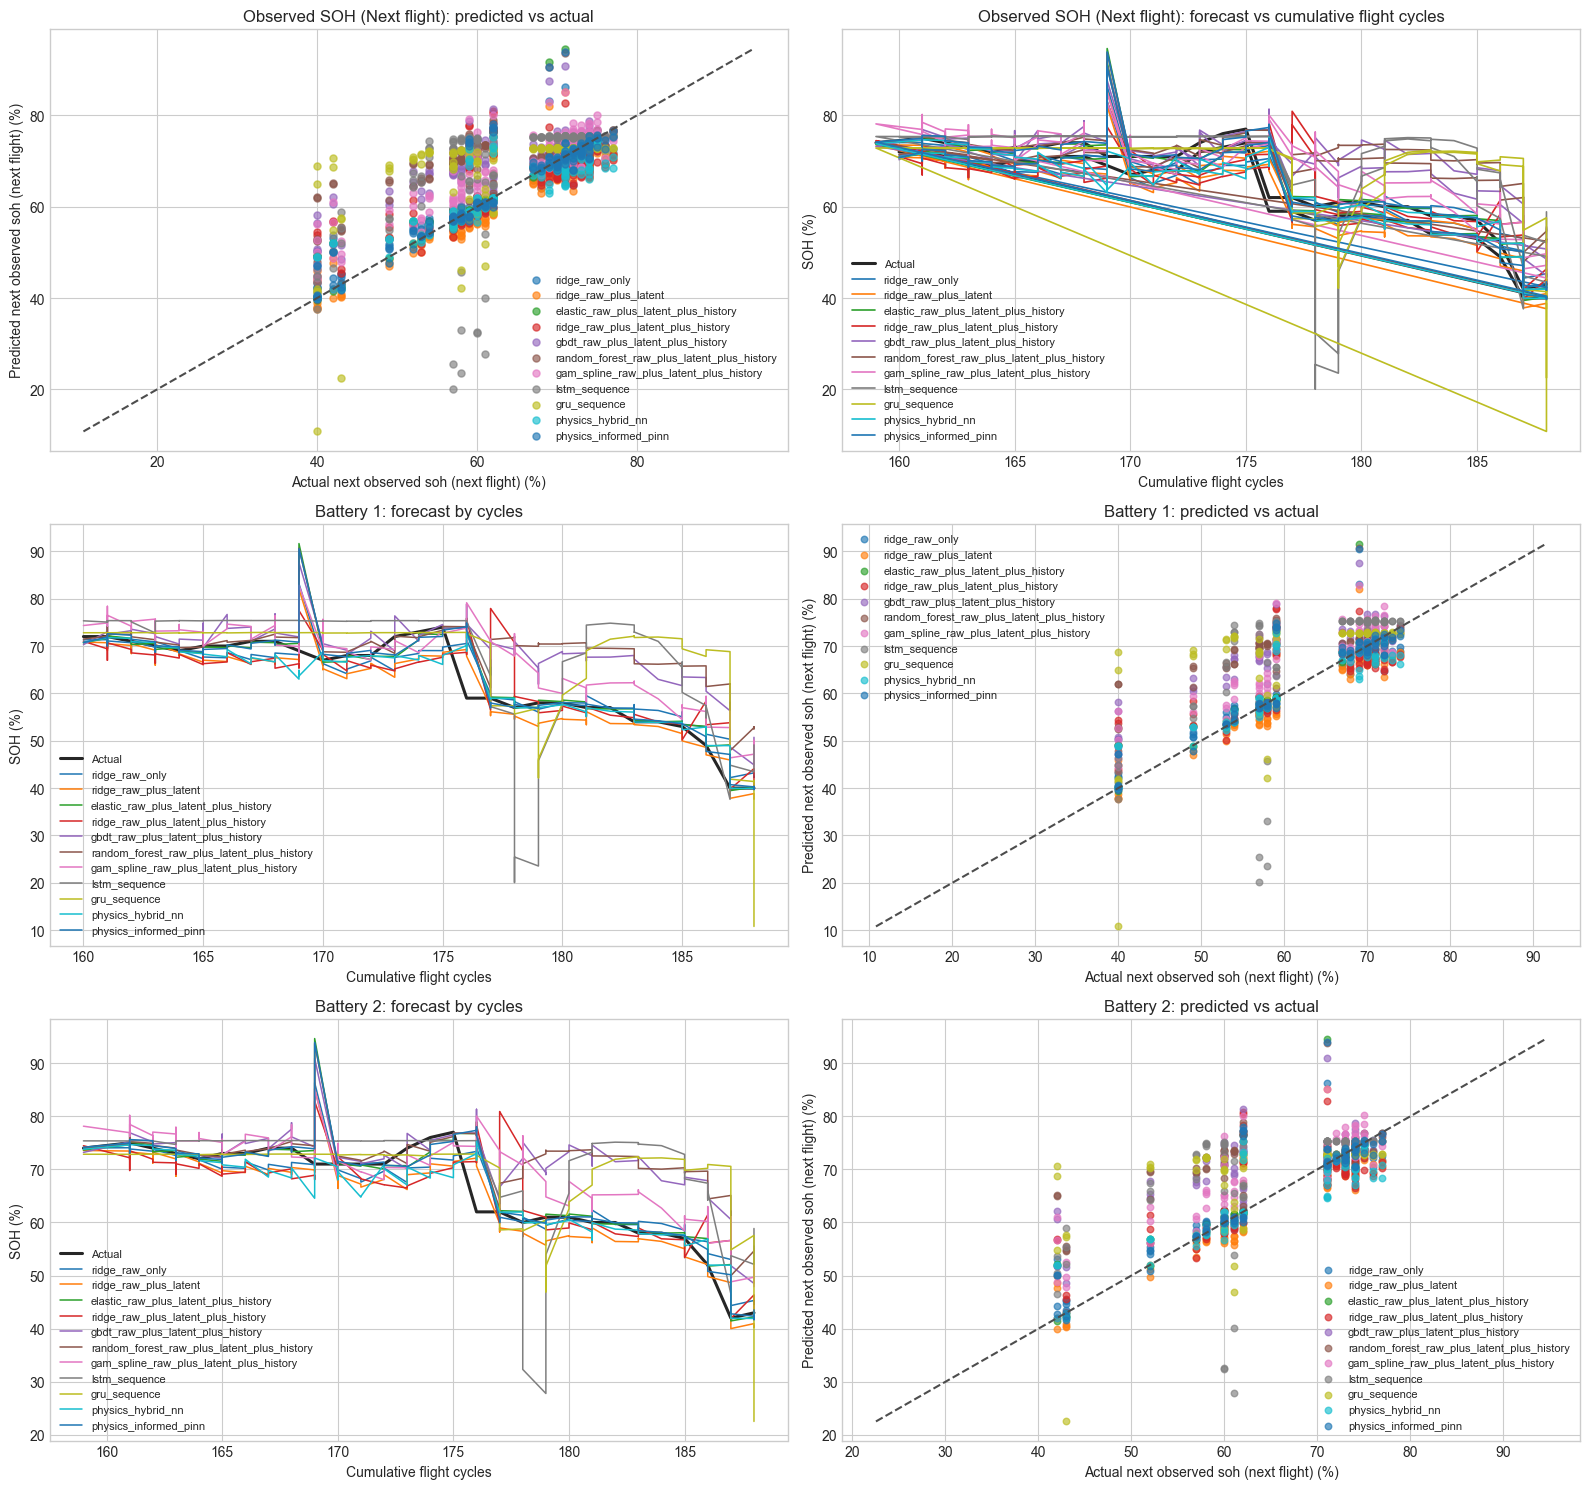

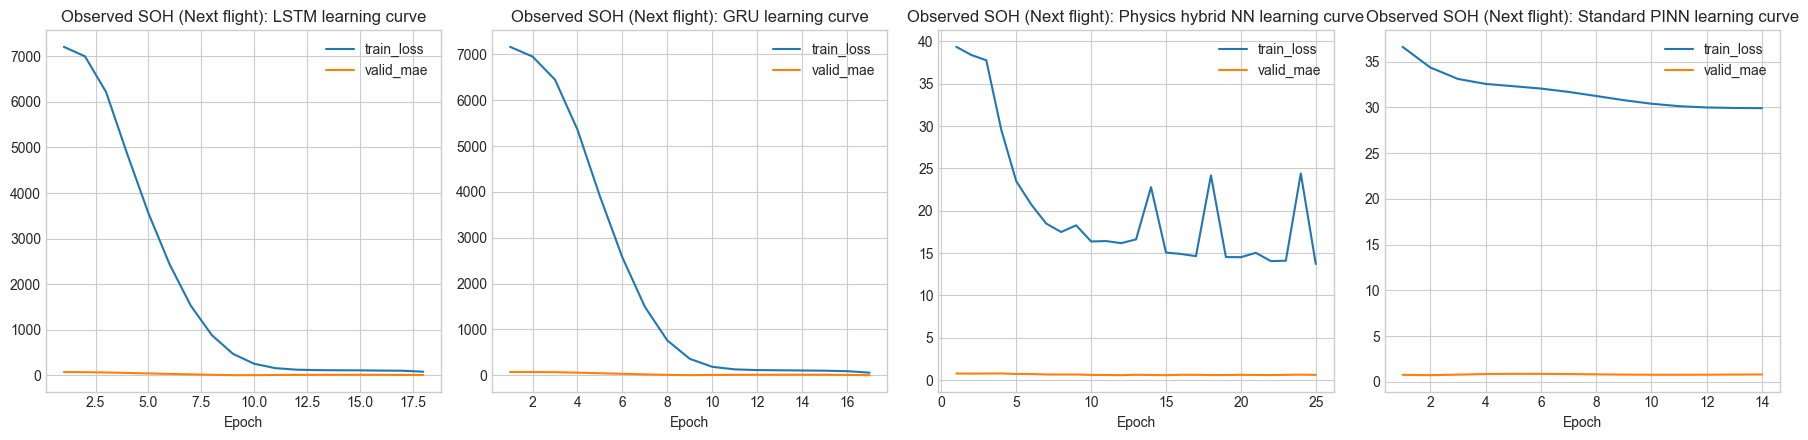

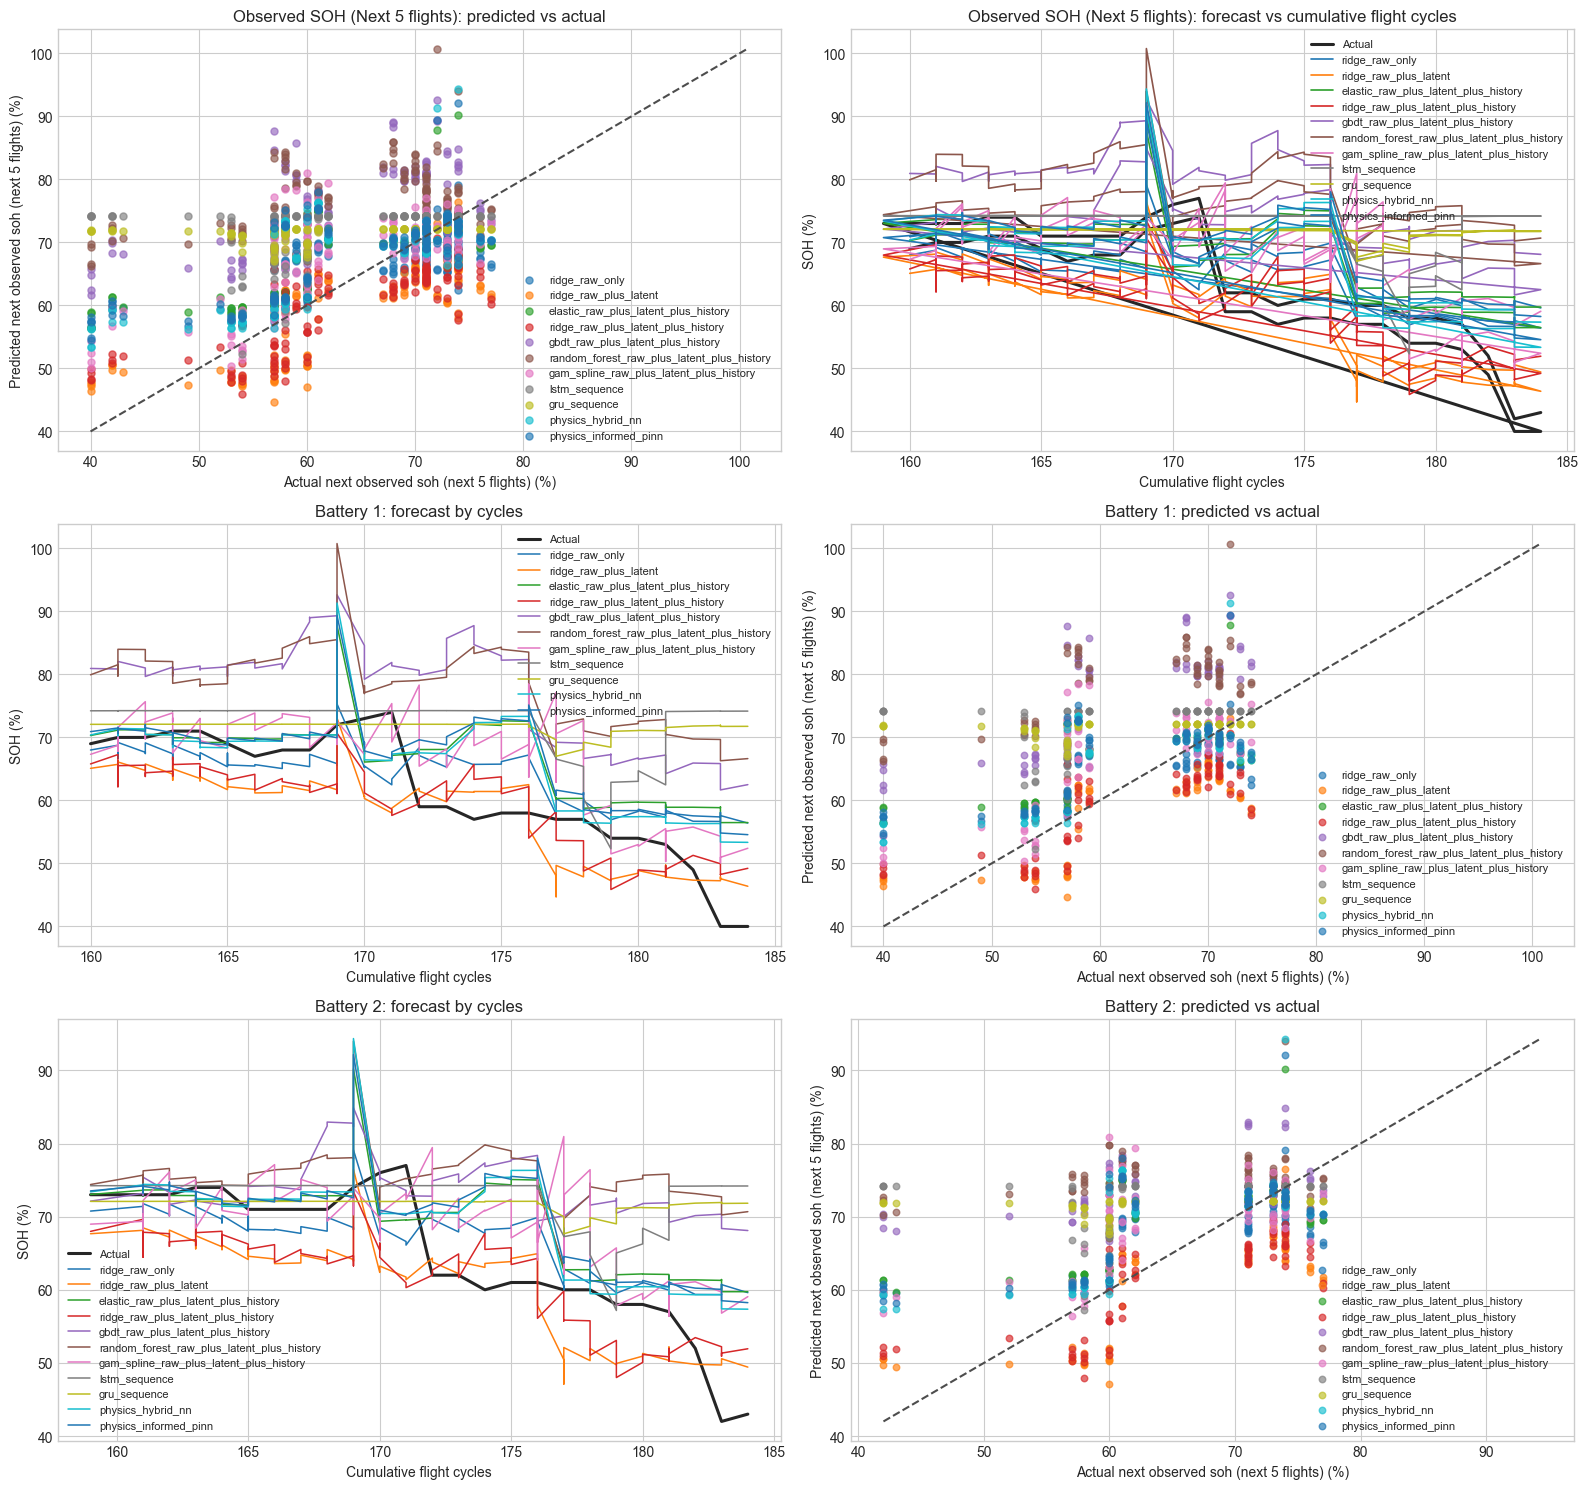

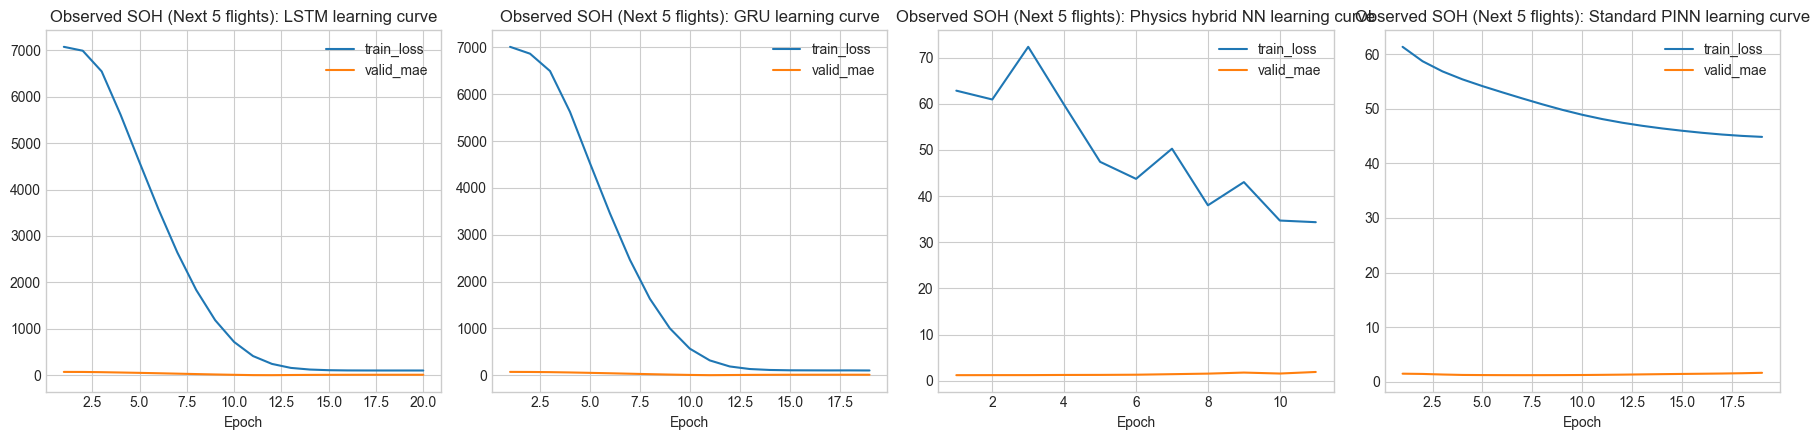

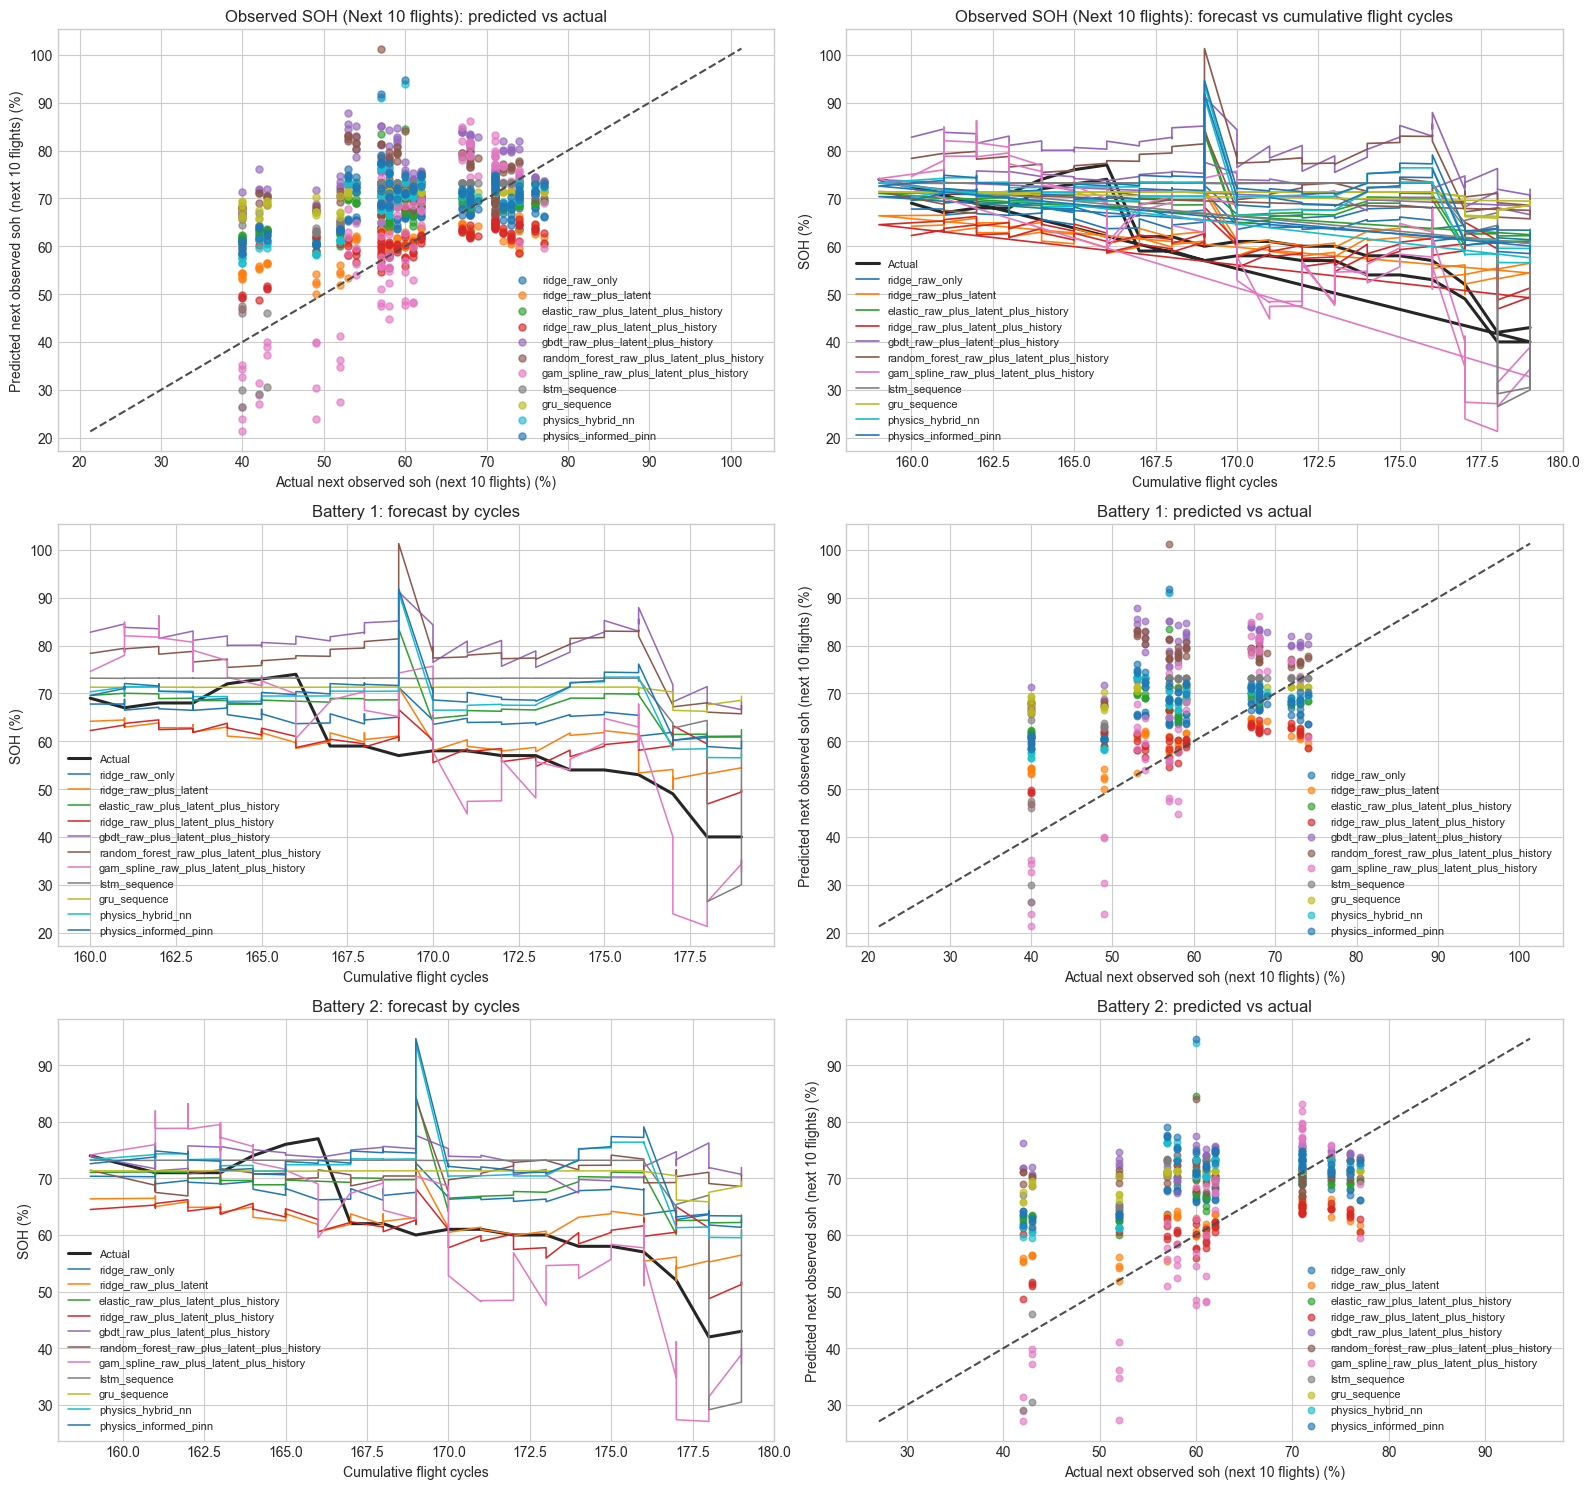

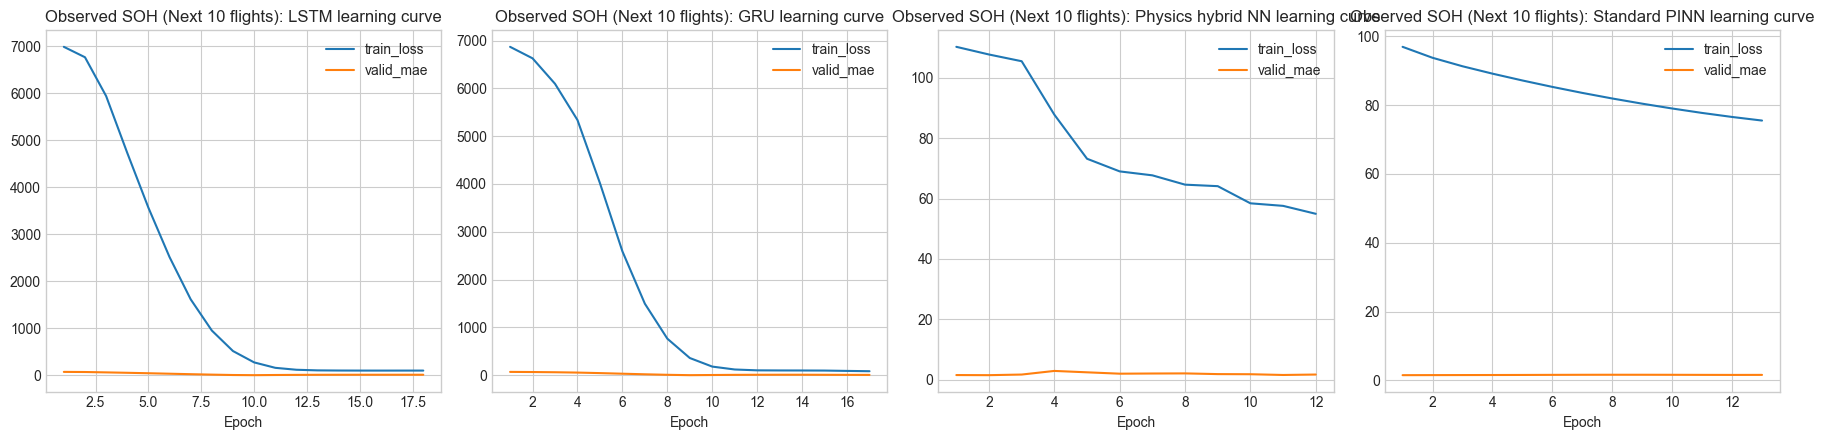

In [6]:
def plot_target_result(result: dict[str, object]) -> None:
    target_spec = result["target_spec"]
    benchmark_df = result["benchmark_df"]
    common_subset_metrics = result["common_subset_metrics"]

    print(f"{target_spec.title_label}: common-subset test metrics")
    display(
        common_subset_metrics.loc[common_subset_metrics["eval_split"].eq("test")]
        .sort_values("level_mae")
        [["model", "level_mae", "level_rmse", "level_r2", "delta_r2"]]
        .round(4)
    )

    test_plot_df = benchmark_df.loc[benchmark_df["split"].eq("test")].copy().sort_values(["battery_id", "cumulative_flight_count", "event_datetime"])
    plot_models = [
        col
        for col in [
            "ridge_raw_only",
            "ridge_raw_plus_latent",
            "elastic_raw_plus_latent_plus_history",
            "ridge_raw_plus_latent_plus_history",
            "gbdt_raw_plus_latent_plus_history",
            "random_forest_raw_plus_latent_plus_history",
            "gam_spline_raw_plus_latent_plus_history",
            "lstm_sequence",
            "gru_sequence",
            "physics_hybrid_nn",
            "physics_informed_pinn",
        ]
        if col in test_plot_df.columns
    ]

    battery_ids = sorted(test_plot_df["battery_id"].dropna().unique().tolist())
    nrows = 1 + len(battery_ids)
    fig, axes = plt.subplots(nrows, 2, figsize=(16, 5 * nrows))
    axes = np.atleast_2d(axes)

    scatter_ax = axes[0, 0]
    cycle_ax = axes[0, 1]
    for model_col in plot_models:
        sub = test_plot_df.loc[test_plot_df[model_col].notna()]
        scatter_ax.scatter(sub[target_spec.next_col], sub[model_col], alpha=0.65, s=26, label=model_col)
    diag_low = min(test_plot_df[target_spec.next_col].min(), *(test_plot_df[col].min() for col in plot_models if test_plot_df[col].notna().any()))
    diag_high = max(test_plot_df[target_spec.next_col].max(), *(test_plot_df[col].max() for col in plot_models if test_plot_df[col].notna().any()))
    scatter_ax.plot([diag_low, diag_high], [diag_low, diag_high], linestyle="--", color="0.3")
    scatter_ax.set_title(f"{target_spec.title_label}: predicted vs actual")
    scatter_ax.set_xlabel(f"Actual next {target_spec.title_label.lower()} (%)")
    scatter_ax.set_ylabel(f"Predicted next {target_spec.title_label.lower()} (%)")
    scatter_ax.legend(loc="best", fontsize=8)

    cycle_ax.plot(test_plot_df["cumulative_flight_count"], test_plot_df[target_spec.next_col], linewidth=2.2, color="0.15", label="Actual")
    for model_col in plot_models:
        cycle_ax.plot(test_plot_df["cumulative_flight_count"], test_plot_df[model_col], linewidth=1.2, label=model_col)
    cycle_ax.set_title(f"{target_spec.title_label}: forecast vs cumulative flight cycles")
    cycle_ax.set_xlabel("Cumulative flight cycles")
    cycle_ax.set_ylabel("SOH (%)")
    cycle_ax.legend(loc="best", fontsize=8)

    for row_idx, battery_id in enumerate(battery_ids, start=1):
        battery_df = test_plot_df.loc[test_plot_df["battery_id"].eq(battery_id)].copy().sort_values(["cumulative_flight_count", "event_datetime"])
        left_ax = axes[row_idx, 0]
        right_ax = axes[row_idx, 1]
        left_ax.plot(battery_df["cumulative_flight_count"], battery_df[target_spec.next_col], linewidth=2.2, color="0.15", label="Actual")
        for model_col in plot_models:
            left_ax.plot(battery_df["cumulative_flight_count"], battery_df[model_col], linewidth=1.1, label=model_col)
        left_ax.set_title(f"Battery {battery_id}: forecast by cycles")
        left_ax.set_xlabel("Cumulative flight cycles")
        left_ax.set_ylabel("SOH (%)")
        left_ax.legend(loc="best", fontsize=8)

        for model_col in plot_models:
            sub = battery_df.loc[battery_df[model_col].notna()]
            right_ax.scatter(sub[target_spec.next_col], sub[model_col], alpha=0.65, s=22, label=model_col)
        low = min(battery_df[target_spec.next_col].min(), *(battery_df[col].min() for col in plot_models if battery_df[col].notna().any()))
        high = max(battery_df[target_spec.next_col].max(), *(battery_df[col].max() for col in plot_models if battery_df[col].notna().any()))
        right_ax.plot([low, high], [low, high], linestyle="--", color="0.3")
        right_ax.set_title(f"Battery {battery_id}: predicted vs actual")
        right_ax.set_xlabel(f"Actual next {target_spec.title_label.lower()} (%)")
        right_ax.set_ylabel(f"Predicted next {target_spec.title_label.lower()} (%)")
        right_ax.legend(loc="best", fontsize=8)

    fig.tight_layout()

    history_map = {
        "LSTM": result["lstm_history_df"],
        "GRU": result["gru_history_df"],
        "Physics hybrid NN": result["hybrid_history_df"],
        "Standard PINN": result["pinn_history_df"],
    }
    fig2, axes2 = plt.subplots(1, 4, figsize=(18, 4.5))
    axes2 = np.atleast_1d(axes2)
    for ax, (label, history_df) in zip(axes2.ravel(), history_map.items()):
        if not history_df.empty:
            ax.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
            ax.plot(history_df["epoch"], history_df["valid_mae"], label="valid_mae")
        ax.set_title(f"{target_spec.title_label}: {label} learning curve")
        ax.set_xlabel("Epoch")
        ax.legend(loc="best")
    fig2.tight_layout()


for result in results.values():
    plot_target_result(result)



## Interpretation scaffold

This prints a compact summary of whether latent features, history features, LSTM, or the physics-informed model actually improved next-step forecasting.

In [7]:
def interpret_result(result: dict[str, object]) -> None:
    target_spec = result["target_spec"]
    metrics_df = result["common_subset_metrics"]
    if metrics_df.empty:
        print(f"No common-subset metrics available for {target_spec.name}.")
        return

    test_metrics = metrics_df.loc[metrics_df["eval_split"].eq("test")].sort_values("level_mae")
    holdout_metrics = metrics_df.loc[metrics_df["eval_split"].eq("holdout")].sort_values("level_mae")

    print(f"{target_spec.title_label} summary")
    if not test_metrics.empty:
        best_test = test_metrics.iloc[0]
        print(
            f"Best test model: {best_test['model']} "
            f"(MAE={best_test['level_mae']:.4f}, RMSE={best_test['level_rmse']:.4f}, R2={best_test['level_r2']:.4f}, delta_R2={best_test['delta_r2']:.4f})"
        )
        display(test_metrics[["model", "level_mae", "level_rmse", "level_r2", "delta_r2"]].round(4))

        raw_mae = get_metric(metrics_df, "test", "ridge_raw_only", "level_mae")
        latent_mae = get_metric(metrics_df, "test", "ridge_raw_plus_latent", "level_mae")
        history_mae = get_metric(metrics_df, "test", "ridge_raw_plus_latent_plus_history", "level_mae")
        elastic_mae = get_metric(metrics_df, "test", "elastic_raw_plus_latent_plus_history", "level_mae")
        lstm_mae = get_metric(metrics_df, "test", "lstm_sequence", "level_mae")
        hybrid_mae = get_metric(metrics_df, "test", "physics_hybrid_nn", "level_mae")
        pinn_mae = get_metric(metrics_df, "test", "physics_informed_pinn", "level_mae")

        if np.isfinite(raw_mae) and np.isfinite(latent_mae):
            print(f"Adding latent features to raw ridge changes test MAE by {latent_mae - raw_mae:+.4f}.")
        if np.isfinite(raw_mae) and np.isfinite(history_mae):
            print(f"Adding latent + history features to ridge changes test MAE by {history_mae - raw_mae:+.4f}.")
        if np.isfinite(history_mae) and np.isfinite(elastic_mae):
            print(f"Elastic net vs ridge-history MAE difference: {elastic_mae - history_mae:+.4f}.")
        if np.isfinite(lstm_mae) and np.isfinite(history_mae):
            print(f"LSTM vs ridge-history MAE difference: {lstm_mae - history_mae:+.4f}.")
        if np.isfinite(hybrid_mae) and np.isfinite(history_mae):
            print(f"Physics hybrid NN vs ridge-history MAE difference: {hybrid_mae - history_mae:+.4f}.")
        if np.isfinite(pinn_mae) and np.isfinite(history_mae):
            print(f"Standard PINN vs ridge-history MAE difference: {pinn_mae - history_mae:+.4f}.")

    if not holdout_metrics.empty:
        best_holdout = holdout_metrics.iloc[0]
        print(
            f"Best holdout model: {best_holdout['model']} "
            f"(MAE={best_holdout['level_mae']:.4f}, RMSE={best_holdout['level_rmse']:.4f}, R2={best_holdout['level_r2']:.4f})"
        )


for result in results.values():
    interpret_result(result)



Observed SOH (Next flight) summary
Best test model: naive_zero_delta (MAE=1.9125, RMSE=4.6864, R2=0.7656, delta_R2=-0.1059)


,model,level_mae,level_rmse,level_r2,delta_r2
24,naive_zero_delta,1.9125,4.6864,0.7656,-0.1059
35,physics_informed_pinn,2.0659,4.5337,0.7806,-0.0349
27,elastic_raw_plus_latent_plus_history,2.1182,4.6735,0.7669,-0.0998
34,physics_hybrid_nn,2.4171,3.9391,0.8344,0.2187
25,ridge_raw_only,2.7956,4.1905,0.8126,0.1158
26,ridge_raw_plus_latent,3.2540,4.1159,0.8192,0.1470
28,ridge_raw_plus_latent_plus_history,4.4472,6.3095,0.5751,-1.0045
31,gam_spline_raw_plus_latent_plus_history,5.3621,6.9298,0.4874,-1.4180
33,gru_sequence,6.3289,9.5016,0.0364,-3.5458
29,gbdt_raw_plus_latent_plus_history,6.5237,8.6945,0.1932,-2.8064


Adding latent features to raw ridge changes test MAE by +0.4584.
Adding latent + history features to ridge changes test MAE by +1.6516.
Elastic net vs ridge-history MAE difference: -2.3290.
LSTM vs ridge-history MAE difference: +3.5170.
Physics hybrid NN vs ridge-history MAE difference: -2.0301.
Standard PINN vs ridge-history MAE difference: -2.3813.
Best holdout model: naive_zero_delta (MAE=0.2222, RMSE=0.5270, R2=0.7391)
Observed SOH (Next 5 flights) summary
Best test model: ridge_raw_only (MAE=5.1457, RMSE=6.5981, R2=0.4832, delta_R2=-0.0098)


,model,level_mae,level_rmse,level_r2,delta_r2
25,ridge_raw_only,5.1457,6.5981,0.4832,-0.0098
34,physics_hybrid_nn,5.1787,7.5586,0.3217,-0.3252
24,naive_zero_delta,5.4779,7.8819,0.2625,-0.4410
31,gam_spline_raw_plus_latent_plus_history,5.5829,7.7011,0.2959,-0.3756
27,elastic_raw_plus_latent_plus_history,5.6339,7.8374,0.2708,-0.4247
35,physics_informed_pinn,5.6731,7.8948,0.2601,-0.4457
28,ridge_raw_plus_latent_plus_history,5.8724,6.6627,0.4730,-0.0297
26,ridge_raw_plus_latent,6.5168,7.2373,0.3782,-0.2149
33,gru_sequence,8.4058,11.6421,-0.6091,-2.1438
32,lstm_sequence,8.5058,11.9532,-0.6962,-2.3141


Adding latent features to raw ridge changes test MAE by +1.3711.
Adding latent + history features to ridge changes test MAE by +0.7267.
Elastic net vs ridge-history MAE difference: -0.2385.
LSTM vs ridge-history MAE difference: +2.6335.
Physics hybrid NN vs ridge-history MAE difference: -0.6937.
Standard PINN vs ridge-history MAE difference: -0.1993.
Best holdout model: physics_hybrid_nn (MAE=0.7841, RMSE=0.8762, R2=-0.3320)
Observed SOH (Next 10 flights) summary
Best test model: ridge_raw_plus_latent (MAE=6.1157, RMSE=7.7371, R2=0.4069, delta_R2=0.1571)


,model,level_mae,level_rmse,level_r2,delta_r2
26,ridge_raw_plus_latent,6.1157,7.7371,0.4069,0.1571
28,ridge_raw_plus_latent_plus_history,6.3646,7.9074,0.3805,0.1196
25,ridge_raw_only,7.9531,9.8119,0.0462,-0.3556
31,gam_spline_raw_plus_latent_plus_history,8.2582,9.9094,0.0272,-0.3826
27,elastic_raw_plus_latent_plus_history,8.8569,11.0059,-0.2001,-0.7056
34,physics_hybrid_nn,9.9423,12.1120,-0.4534,-1.0656
32,lstm_sequence,10.1474,12.0806,-0.4459,-1.0549
24,naive_zero_delta,10.3421,12.5555,-0.5618,-1.2197
33,gru_sequence,10.6844,13.3214,-0.7581,-1.4987
35,physics_informed_pinn,10.8655,13.1942,-0.7247,-1.4513


Adding latent features to raw ridge changes test MAE by -1.8373.
Adding latent + history features to ridge changes test MAE by -1.5885.
Elastic net vs ridge-history MAE difference: +2.4924.
LSTM vs ridge-history MAE difference: +3.7829.
Physics hybrid NN vs ridge-history MAE difference: +3.5777.
Standard PINN vs ridge-history MAE difference: +4.5010.
Best holdout model: physics_hybrid_nn (MAE=0.6618, RMSE=0.7424, R2=0.2836)
